# Data and libraries' imports

In [1]:
import numpy as np, pandas as pd,matplotlib.pyplot as plt, seaborn as sns,openpyxl
import re
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score
import sqlite3

In [2]:
conn = sqlite3.connect("../sql/real_estate.db")

In [3]:
df = pd.read_sql_query("SELECT * FROM apartments", conn)
df.head()

,Title,Location,Rooms,Shower Rooms,Area,Housing stock,Price,Floor,Heating,Has furniture,Has AC,Has underfloor heating,Has double glazed windows,URL
0,"Apartament cu 1 cameră, sect. Botanica","Strada Dimineții Chișinău, Chișinău",1.0,1.0,42 m²,Bloc Nou,73.500 EUR,5 / 12,Autonomă,1,0,0,0,https://immobiliare.md/listing/apartament-cu-1...
1,"Apartament cu 2 camere, sect. Centru","Strada Albișoara Chișinău, Chișinău",2.0,1.0,53 m²,Secundar (Vechi),109.000 EUR,1 / 9,Autonomă,1,0,0,1,https://immobiliare.md/listing/apartament-cu-2...
2,"Apartament cu 2 camere, sect. Botanica","Strada Nikolai Zelinski Chișinău, Chișinău",2.0,1.0,47 m²,Secundar (Vechi),93.000 EUR,5 / 5,Centralizată,1,0,0,1,https://immobiliare.md/listing/apartament-cu-2...
3,"Apartament cu 2 camere, sect. Botanica","Strada Burebista Chișinău, Chișinău",2.0,1.0,75 m²,Bloc Nou,175.000 EUR,8 / 10,Autonomă,1,1,1,1,https://immobiliare.md/listing/apartament-cu-2...
4,"Apartament cu 1 cameră, sect. Botanica","Strada Burebista Chișinău, Chișinău",1.0,1.0,43 m²,Bloc Nou,109.000 EUR,9 / 10,Autonomă,1,1,1,1,https://immobiliare.md/listing/apartament-cu-1...


In [4]:
pd.set_option('display.max_colwidth', None)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 574 entries, 0 to 573
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Title                      574 non-null    str    
 1   Location                   574 non-null    str    
 2   Rooms                      573 non-null    float64
 3   Shower Rooms               573 non-null    float64
 4   Area                       574 non-null    str    
 5   Housing stock              574 non-null    str    
 6   Price                      574 non-null    str    
 7   Floor                      565 non-null    str    
 8   Heating                    341 non-null    str    
 9   Has furniture              574 non-null    int64  
 10  Has AC                     574 non-null    int64  
 11  Has underfloor heating     574 non-null    int64  
 12  Has double glazed windows  574 non-null    int64  
 13  URL                        574 non-null    str    
dtypes: fl

In [6]:
df.groupby('Rooms')['Price'].count()

Rooms
1.0    164
2.0    297
3.0     97
4.0     15
Name: Price, dtype: int64

# Questions

What sector's is more stable? -   lowest gap between mean and median  (stability here means low price dispersion)  
Which feature adds the most value?  - highest correlation with price  
Is price linear with m^2 and is there a change with high total area? - analysing the gragh of area and price and analysing different regression models.   
How much does sector influence price compared to area?  - comparison in coefficients of sector and area in a model 


# Data cleaning

## Removing irrelevant data

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
# No duplicates

## Handling missing values

In [9]:
df['Rooms'].isna().sum()

np.int64(1)

In [10]:
df[df['Rooms'].isna()]

,Title,Location,Rooms,Shower Rooms,Area,Housing stock,Price,Floor,Heating,Has furniture,Has AC,Has underfloor heating,Has double glazed windows,URL
155,"Apartament cu 1 cameră, sect. Botanica","Strada Independenței Chișinău, Chișinău",NaN,1.0,32 m²,Secundar (Vechi),57.500 EUR,7 / 7,Autonomă,1,1,0,1,https://immobiliare.md/listing/apartament-cu-1-camera-sect-botanica-6tip0


In [11]:
#It is a signle room apartment
df.loc[df['Rooms'].isna(),'Rooms'] = 1

In [12]:
df['Shower Rooms'].isna().sum()

np.int64(1)

In [13]:
df[df['Shower Rooms'].isna()]

,Title,Location,Rooms,Shower Rooms,Area,Housing stock,Price,Floor,Heating,Has furniture,Has AC,Has underfloor heating,Has double glazed windows,URL
529,"Apartament cu 1 cameră, sect. Râșcani","str. Circului, Chișinău, Chișinău",1.0,NaN,49 m²,Bloc Nou,121.500 EUR,3/4,NaN,1,0,1,0,https://immobiliare.md/listing/apartament-cu-1-camera-sect-rascani-au03z


The number of apartments without bathroom mention is 1. I will fill it with 1.

In [14]:
df.loc[df['Shower Rooms'].isna(),'Shower Rooms'] = 1

After inspecting, apartment 85 is most likely for rent. It needs to be deleted

In [15]:
df = df[df['URL'] != 'https://immobiliare.md/listing/rascani-2-camere-1776181444143849']

## Standardizing data formats and names

In [16]:
df.head()

,Title,Location,Rooms,Shower Rooms,Area,Housing stock,Price,Floor,Heating,Has furniture,Has AC,Has underfloor heating,Has double glazed windows,URL
0,"Apartament cu 1 cameră, sect. Botanica","Strada Dimineții Chișinău, Chișinău",1.0,1.0,42 m²,Bloc Nou,73.500 EUR,5 / 12,Autonomă,1,0,0,0,https://immobiliare.md/listing/apartament-cu-1-camera-sect-botanica-l7mqr
1,"Apartament cu 2 camere, sect. Centru","Strada Albișoara Chișinău, Chișinău",2.0,1.0,53 m²,Secundar (Vechi),109.000 EUR,1 / 9,Autonomă,1,0,0,1,https://immobiliare.md/listing/apartament-cu-2-camere-sect-centru-rtgjw
2,"Apartament cu 2 camere, sect. Botanica","Strada Nikolai Zelinski Chișinău, Chișinău",2.0,1.0,47 m²,Secundar (Vechi),93.000 EUR,5 / 5,Centralizată,1,0,0,1,https://immobiliare.md/listing/apartament-cu-2-camere-sect-botanica-vz188
3,"Apartament cu 2 camere, sect. Botanica","Strada Burebista Chișinău, Chișinău",2.0,1.0,75 m²,Bloc Nou,175.000 EUR,8 / 10,Autonomă,1,1,1,1,https://immobiliare.md/listing/apartament-cu-2-camere-sect-botanica-19n2c
4,"Apartament cu 1 cameră, sect. Botanica","Strada Burebista Chișinău, Chișinău",1.0,1.0,43 m²,Bloc Nou,109.000 EUR,9 / 10,Autonomă,1,1,1,1,https://immobiliare.md/listing/apartament-cu-1-camera-sect-botanica-bff82


In [17]:
df["Price"] = df["Price"].str.split(r"\s").str[0]
df["Area"] = df["Area"].str.split(r"\s").str[0]

In [18]:
df = df.rename({'Area': 'Area m²','Price': 'Price (thousands of €)'},axis = 1)
df.head(5)

,Title,Location,Rooms,Shower Rooms,Area m²,Housing stock,Price (thousands of €),Floor,Heating,Has furniture,Has AC,Has underfloor heating,Has double glazed windows,URL
0,"Apartament cu 1 cameră, sect. Botanica","Strada Dimineții Chișinău, Chișinău",1.0,1.0,42,Bloc Nou,73.500,5 / 12,Autonomă,1,0,0,0,https://immobiliare.md/listing/apartament-cu-1-camera-sect-botanica-l7mqr
1,"Apartament cu 2 camere, sect. Centru","Strada Albișoara Chișinău, Chișinău",2.0,1.0,53,Secundar (Vechi),109.000,1 / 9,Autonomă,1,0,0,1,https://immobiliare.md/listing/apartament-cu-2-camere-sect-centru-rtgjw
2,"Apartament cu 2 camere, sect. Botanica","Strada Nikolai Zelinski Chișinău, Chișinău",2.0,1.0,47,Secundar (Vechi),93.000,5 / 5,Centralizată,1,0,0,1,https://immobiliare.md/listing/apartament-cu-2-camere-sect-botanica-vz188
3,"Apartament cu 2 camere, sect. Botanica","Strada Burebista Chișinău, Chișinău",2.0,1.0,75,Bloc Nou,175.000,8 / 10,Autonomă,1,1,1,1,https://immobiliare.md/listing/apartament-cu-2-camere-sect-botanica-19n2c
4,"Apartament cu 1 cameră, sect. Botanica","Strada Burebista Chișinău, Chișinău",1.0,1.0,43,Bloc Nou,109.000,9 / 10,Autonomă,1,1,1,1,https://immobiliare.md/listing/apartament-cu-1-camera-sect-botanica-bff82


In [19]:
df = df.astype({
    'Rooms': int,
    'Shower Rooms': int,
    'Area m²': float,
    'Price (thousands of €)': float
})

In [20]:
total_floors = df['Floor'].str.split('/').str[1]
df.insert(8,'Total Floors',total_floors)
df['Floor'] = df['Floor'].str.split('/').str[0]

In [21]:
df.head()

,Title,Location,Rooms,Shower Rooms,Area m²,Housing stock,Price (thousands of €),Floor,Total Floors,Heating,Has furniture,Has AC,Has underfloor heating,Has double glazed windows,URL
0,"Apartament cu 1 cameră, sect. Botanica","Strada Dimineții Chișinău, Chișinău",1,1,42.0,Bloc Nou,73.5,5,12,Autonomă,1,0,0,0,https://immobiliare.md/listing/apartament-cu-1-camera-sect-botanica-l7mqr
1,"Apartament cu 2 camere, sect. Centru","Strada Albișoara Chișinău, Chișinău",2,1,53.0,Secundar (Vechi),109.0,1,9,Autonomă,1,0,0,1,https://immobiliare.md/listing/apartament-cu-2-camere-sect-centru-rtgjw
2,"Apartament cu 2 camere, sect. Botanica","Strada Nikolai Zelinski Chișinău, Chișinău",2,1,47.0,Secundar (Vechi),93.0,5,5,Centralizată,1,0,0,1,https://immobiliare.md/listing/apartament-cu-2-camere-sect-botanica-vz188
3,"Apartament cu 2 camere, sect. Botanica","Strada Burebista Chișinău, Chișinău",2,1,75.0,Bloc Nou,175.0,8,10,Autonomă,1,1,1,1,https://immobiliare.md/listing/apartament-cu-2-camere-sect-botanica-19n2c
4,"Apartament cu 1 cameră, sect. Botanica","Strada Burebista Chișinău, Chișinău",1,1,43.0,Bloc Nou,109.0,9,10,Autonomă,1,1,1,1,https://immobiliare.md/listing/apartament-cu-1-camera-sect-botanica-bff82


### Price and area plotting to see outliers

In [22]:
price = df['Price (thousands of €)']
area = df['Area m²']

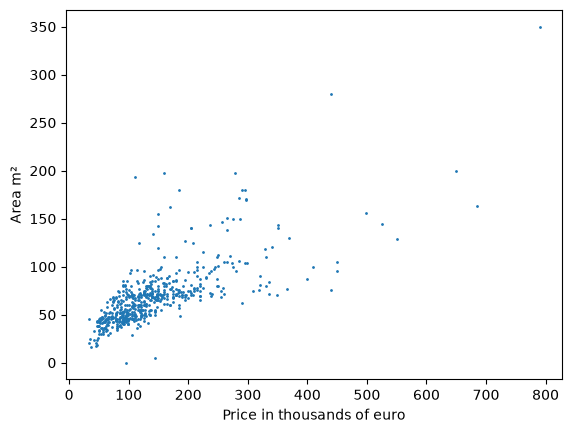

In [23]:
plt.scatter(price,area,1)
plt.xlabel("Price in thousands of euro")
plt.ylabel("Area m²")
plt.show()

Some outliers need to be inspected

In [24]:
df[df['Area m²'] > 190]

,Title,Location,Rooms,Shower Rooms,Area m²,Housing stock,Price (thousands of €),Floor,Total Floors,Heating,Has furniture,Has AC,Has underfloor heating,Has double glazed windows,URL
329,"Penthouse cu 3 camere, sect. Botanica","str. Burebista, Chișinău, Chișinău",3,3,280.0,Bloc Nou,440.0,15,16,Autonomă,1,1,1,1,https://immobiliare.md/listing/penthouse-cu-3-camere-sect-botanica-aawsv
330,"Apartament la sol cu 4 camere, sect. Centru","str. Alexei Sciusev, Chișinău, Chișinău",4,3,198.0,Secundar (Vechi),279.0,1,1,Autonomă,1,1,1,1,https://immobiliare.md/listing/apartament-la-sol-cu-4-camere-sect-centru-zgdpn
394,"Penthouse cu 2 niveluri, sect. Botanica","str. Grenoble, Chișinău, Chișinău",4,3,350.0,Bloc Nou,790.0,NaN,NaN,Autonomă,1,1,1,1,https://immobiliare.md/listing/penthouse-cu-2-niveluri-sect-botanica-cfno4
405,"Penthouse cu 2 niveluri, sect. Botanica","str. Decebal, Chișinău, Chișinău",3,2,200.0,Bloc Nou,650.0,9,10,Autonomă,1,1,1,1,https://immobiliare.md/listing/penthouse-cu-2-niveluri-sect-botanica-48gud
555,"Casă cu 2 niveluri, loc. Hulboaca,com Grătiești","Hulboaca, com. Grătiești, Chișinău, Chișinău",4,3,198.0,Bloc Nou,159.0,2,2,Autonomă,1,0,0,0,https://immobiliare.md/listing/casa-cu-2-niveluri-loc-hulboacacom-gratiesti-ekrk4
567,"Penthouse cu 2 camere, or. Tiraspol","Tiraspol, str. 1 Mai, Chișinău, Chișinău",2,2,193.0,Bloc Nou,110.0,11,11,Autonomă,1,1,1,1,https://immobiliare.md/listing/penthouse-cu-2-camere-or-tiraspol-dmd8i


There is a house. It should be removed because we analyse apartments only

It would be useful to see if there are other houses in this dataframe

In [25]:
df[df['Title'].str.contains("Casă")]

,Title,Location,Rooms,Shower Rooms,Area m²,Housing stock,Price (thousands of €),Floor,Total Floors,Heating,Has furniture,Has AC,Has underfloor heating,Has double glazed windows,URL
268,"Casă, com. Băcioi","str. Sfânta Treime, Chișinău, Chișinău",4,2,138.0,Bloc Nou,264.9,NaN,NaN,Autonomă,1,0,1,0,https://immobiliare.md/listing/casa-com-bacioi-7lufp
409,"Casă cu 2 niveluri, com. Dumbrava","Dumbrava, str. Mugurel, Chișinău, Chișinău",4,2,180.0,Bloc Nou,185.0,NaN,NaN,NaN,1,0,0,0,https://immobiliare.md/listing/casa-cu-2-niveluri-com-dumbrava-2nfn4
555,"Casă cu 2 niveluri, loc. Hulboaca,com Grătiești","Hulboaca, com. Grătiești, Chișinău, Chișinău",4,3,198.0,Bloc Nou,159.0,2,2,Autonomă,1,0,0,0,https://immobiliare.md/listing/casa-cu-2-niveluri-loc-hulboacacom-gratiesti-ekrk4


They all must be deleted

In [26]:
df = df[~df['Title'].str.contains("Casă")]
df.shape

(571, 15)

### 

Created a dictionary to group data in 5 sectors - Centru, Botanica, Ciocana, Rascani, Buiucani

In [27]:
df_sectors = {
    'centru': 'Centru',
    'ceucari': 'Centru',
    'hrusca': 'Centru',
    'melestiu': 'Centru',
    'schinoasa': 'Centru',
    'telecentru': 'Centru',
    'valea dicescu': 'Centru',

    'botanica': 'Botanica',
    'frumușica': 'Botanica',
    'galata': 'Botanica',
    'mălina mare': 'Botanica',
    'muncești': 'Botanica',

    'ciocana': 'Ciocana',
    'otovasca': 'Ciocana',

    'rîșcani': 'Râșcani',
    'râșcani': 'Râșcani',
    'petricani': 'Râșcani',
    'poșta veche': 'Râșcani',
    'visterniceni': 'Râșcani',

    'buiucani': 'Buiucani',
    'sculeni': 'Buiucani'

}

In [28]:
df['Sector'] = df['Title'].str.lower().str.split(r'.').str[1].str[1:].map(df_sectors)

All apartments outside of Chisinau are outside of the scope of this analysis. They will be removed.

In [29]:
df = df[~df['Sector'].isna()]

In [30]:
df.info()

<class 'pandas.DataFrame'>
Index: 452 entries, 0 to 573
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Title                      452 non-null    str    
 1   Location                   452 non-null    str    
 2   Rooms                      452 non-null    int64  
 3   Shower Rooms               452 non-null    int64  
 4   Area m²                    452 non-null    float64
 5   Housing stock              452 non-null    str    
 6   Price (thousands of €)     452 non-null    float64
 7   Floor                      449 non-null    object 
 8   Total Floors               449 non-null    object 
 9   Heating                    271 non-null    str    
 10  Has furniture              452 non-null    int64  
 11  Has AC                     452 non-null    int64  
 12  Has underfloor heating     452 non-null    int64  
 13  Has double glazed windows  452 non-null    int64  
 14  URL       

In [31]:
col = df.pop('Sector')
df.insert(1,'Sector',col)

In [32]:
df.head()

,Title,Sector,Location,Rooms,Shower Rooms,Area m²,Housing stock,Price (thousands of €),Floor,Total Floors,Heating,Has furniture,Has AC,Has underfloor heating,Has double glazed windows,URL
0,"Apartament cu 1 cameră, sect. Botanica",Botanica,"Strada Dimineții Chișinău, Chișinău",1,1,42.0,Bloc Nou,73.5,5,12,Autonomă,1,0,0,0,https://immobiliare.md/listing/apartament-cu-1-camera-sect-botanica-l7mqr
1,"Apartament cu 2 camere, sect. Centru",Centru,"Strada Albișoara Chișinău, Chișinău",2,1,53.0,Secundar (Vechi),109.0,1,9,Autonomă,1,0,0,1,https://immobiliare.md/listing/apartament-cu-2-camere-sect-centru-rtgjw
2,"Apartament cu 2 camere, sect. Botanica",Botanica,"Strada Nikolai Zelinski Chișinău, Chișinău",2,1,47.0,Secundar (Vechi),93.0,5,5,Centralizată,1,0,0,1,https://immobiliare.md/listing/apartament-cu-2-camere-sect-botanica-vz188
3,"Apartament cu 2 camere, sect. Botanica",Botanica,"Strada Burebista Chișinău, Chișinău",2,1,75.0,Bloc Nou,175.0,8,10,Autonomă,1,1,1,1,https://immobiliare.md/listing/apartament-cu-2-camere-sect-botanica-19n2c
4,"Apartament cu 1 cameră, sect. Botanica",Botanica,"Strada Burebista Chișinău, Chișinău",1,1,43.0,Bloc Nou,109.0,9,10,Autonomă,1,1,1,1,https://immobiliare.md/listing/apartament-cu-1-camera-sect-botanica-bff82


In [33]:
df['Housing stock'].value_counts()

Housing stock
Bloc Nou            331
Secundar (Vechi)    118
În construcție        3
Name: count, dtype: int64

In [34]:
df[df['Housing stock'] == 'În construcție']

,Title,Sector,Location,Rooms,Shower Rooms,Area m²,Housing stock,Price (thousands of €),Floor,Total Floors,Heating,Has furniture,Has AC,Has underfloor heating,Has double glazed windows,URL
35,"Apartament cu 1 cameră, sect. Botanica",Botanica,"Bulevardul Dacia Chișinău, Chișinău",1,1,38.40,În construcție,48.75,15,20,Autonomă,1,0,0,0,https://immobiliare.md/listing/apartament-cu-1-camera-sect-botanica-v16ot
36,"Apartament cu 1 cameră, sect. Botanica",Botanica,"Bulevardul Dacia Chișinău, Chișinău",1,1,38.40,În construcție,48.75,17,20,Autonomă,1,0,0,0,https://immobiliare.md/listing/apartament-cu-1-camera-sect-botanica-bqz10
62,"Apartament cu 1 cameră, sect. Botanica",Botanica,"Strada Grădina Botanică Chișinău, Chișinău",1,1,52.25,În construcție,84.90,11,16,Autonomă,1,0,0,0,https://immobiliare.md/listing/apartament-cu-1-camera-sect-botanica-gafco


Will merge "In Constructie" to  "Bloc nou" because there are only 3 records

In [35]:
df["Housing stock"] = df["Housing stock"].replace(
    "În construcție", "Bloc Nou"
)

At this point location is useless. It should be droped.

In [36]:
df = df.drop(['Location'], axis = 1)
df.head(5)

,Title,Sector,Rooms,Shower Rooms,Area m²,Housing stock,Price (thousands of €),Floor,Total Floors,Heating,Has furniture,Has AC,Has underfloor heating,Has double glazed windows,URL
0,"Apartament cu 1 cameră, sect. Botanica",Botanica,1,1,42.0,Bloc Nou,73.5,5,12,Autonomă,1,0,0,0,https://immobiliare.md/listing/apartament-cu-1-camera-sect-botanica-l7mqr
1,"Apartament cu 2 camere, sect. Centru",Centru,2,1,53.0,Secundar (Vechi),109.0,1,9,Autonomă,1,0,0,1,https://immobiliare.md/listing/apartament-cu-2-camere-sect-centru-rtgjw
2,"Apartament cu 2 camere, sect. Botanica",Botanica,2,1,47.0,Secundar (Vechi),93.0,5,5,Centralizată,1,0,0,1,https://immobiliare.md/listing/apartament-cu-2-camere-sect-botanica-vz188
3,"Apartament cu 2 camere, sect. Botanica",Botanica,2,1,75.0,Bloc Nou,175.0,8,10,Autonomă,1,1,1,1,https://immobiliare.md/listing/apartament-cu-2-camere-sect-botanica-19n2c
4,"Apartament cu 1 cameră, sect. Botanica",Botanica,1,1,43.0,Bloc Nou,109.0,9,10,Autonomă,1,1,1,1,https://immobiliare.md/listing/apartament-cu-1-camera-sect-botanica-bff82


## Feature engineering
Note. Here i noticed scraper's bug. After fixing floor extraction, misleading information will not be present in floor column (e.g. 8/1)

In [37]:
df[df['Floor'].str.split("/").str[1] == '1']

,Title,Sector,Rooms,Shower Rooms,Area m²,Housing stock,Price (thousands of €),Floor,Total Floors,Heating,Has furniture,Has AC,Has underfloor heating,Has double glazed windows,URL


In [38]:
df[df['Floor'].isna()]

,Title,Sector,Rooms,Shower Rooms,Area m²,Housing stock,Price (thousands of €),Floor,Total Floors,Heating,Has furniture,Has AC,Has underfloor heating,Has double glazed windows,URL
120,"Apartament cu 3 camere, sect. Telecentru",Centru,3,2,74.0,Bloc Nou,95.0,NaN,NaN,Autonomă,1,0,0,0,https://immobiliare.md/listing/apartament-cu-3-camere-sect-telecentru-vj4rn
394,"Penthouse cu 2 niveluri, sect. Botanica",Botanica,4,3,350.0,Bloc Nou,790.0,NaN,NaN,Autonomă,1,1,1,1,https://immobiliare.md/listing/penthouse-cu-2-niveluri-sect-botanica-cfno4
552,"Apartament cu 2 camere, sect. Ciocana",Ciocana,2,1,57.0,Bloc Nou,107.0,NaN,NaN,Autonomă,1,1,1,1,https://immobiliare.md/listing/apartament-cu-2-camere-sect-ciocana-wcux2


 3 rows with NaN values in floors. They won't be droped because they do not represent core features like area or price

In [39]:
df['Floor'] = df['Floor'].astype('Int64')
df['Total Floors'] = df['Total Floors'].astype('Int64')

In [40]:
df.head(5)

,Title,Sector,Rooms,Shower Rooms,Area m²,Housing stock,Price (thousands of €),Floor,Total Floors,Heating,Has furniture,Has AC,Has underfloor heating,Has double glazed windows,URL
0,"Apartament cu 1 cameră, sect. Botanica",Botanica,1,1,42.0,Bloc Nou,73.5,5,12,Autonomă,1,0,0,0,https://immobiliare.md/listing/apartament-cu-1-camera-sect-botanica-l7mqr
1,"Apartament cu 2 camere, sect. Centru",Centru,2,1,53.0,Secundar (Vechi),109.0,1,9,Autonomă,1,0,0,1,https://immobiliare.md/listing/apartament-cu-2-camere-sect-centru-rtgjw
2,"Apartament cu 2 camere, sect. Botanica",Botanica,2,1,47.0,Secundar (Vechi),93.0,5,5,Centralizată,1,0,0,1,https://immobiliare.md/listing/apartament-cu-2-camere-sect-botanica-vz188
3,"Apartament cu 2 camere, sect. Botanica",Botanica,2,1,75.0,Bloc Nou,175.0,8,10,Autonomă,1,1,1,1,https://immobiliare.md/listing/apartament-cu-2-camere-sect-botanica-19n2c
4,"Apartament cu 1 cameră, sect. Botanica",Botanica,1,1,43.0,Bloc Nou,109.0,9,10,Autonomă,1,1,1,1,https://immobiliare.md/listing/apartament-cu-1-camera-sect-botanica-bff82


In [41]:
df = df.rename({'Heating': 'Autonom Heating'},axis = 1)

In [42]:
df['Autonom Heating'].value_counts(dropna=False)

Autonom Heating
Autonomă        209
NaN             181
Centralizată     62
Name: count, dtype: int64

### Encoding and filling missing values in heating.

In [43]:
heating_map = {
    'Autonomă' : 'Autonomă',
    'Autonomă (gaz)': 'Autonomă',
    'Centralizată': 'Centralizată'
}

In [44]:
df['Autonom Heating'] = df['Autonom Heating'].map(heating_map)

In [45]:
df[df['Autonom Heating'] == 'Apartament cu 1 cameră, sect. Botanica'] 

,Title,Sector,Rooms,Shower Rooms,Area m²,Housing stock,Price (thousands of €),Floor,Total Floors,Autonom Heating,Has furniture,Has AC,Has underfloor heating,Has double glazed windows,URL


In [46]:
df['Autonom Heating'] = df['Autonom Heating'] == 'Autonomă'

In [47]:
df.head(5)

,Title,Sector,Rooms,Shower Rooms,Area m²,Housing stock,Price (thousands of €),Floor,Total Floors,Autonom Heating,Has furniture,Has AC,Has underfloor heating,Has double glazed windows,URL
0,"Apartament cu 1 cameră, sect. Botanica",Botanica,1,1,42.0,Bloc Nou,73.5,5,12,True,1,0,0,0,https://immobiliare.md/listing/apartament-cu-1-camera-sect-botanica-l7mqr
1,"Apartament cu 2 camere, sect. Centru",Centru,2,1,53.0,Secundar (Vechi),109.0,1,9,True,1,0,0,1,https://immobiliare.md/listing/apartament-cu-2-camere-sect-centru-rtgjw
2,"Apartament cu 2 camere, sect. Botanica",Botanica,2,1,47.0,Secundar (Vechi),93.0,5,5,False,1,0,0,1,https://immobiliare.md/listing/apartament-cu-2-camere-sect-botanica-vz188
3,"Apartament cu 2 camere, sect. Botanica",Botanica,2,1,75.0,Bloc Nou,175.0,8,10,True,1,1,1,1,https://immobiliare.md/listing/apartament-cu-2-camere-sect-botanica-19n2c
4,"Apartament cu 1 cameră, sect. Botanica",Botanica,1,1,43.0,Bloc Nou,109.0,9,10,True,1,1,1,1,https://immobiliare.md/listing/apartament-cu-1-camera-sect-botanica-bff82


Those NaN values became False 

### Encoding values in housing stock.

In [48]:
df = pd.get_dummies(df,columns = ["Housing stock"], drop_first = True)

In [49]:
df.head()

,Title,Sector,Rooms,Shower Rooms,Area m²,Price (thousands of €),Floor,Total Floors,Autonom Heating,Has furniture,Has AC,Has underfloor heating,Has double glazed windows,URL,Housing stock_Secundar (Vechi)
0,"Apartament cu 1 cameră, sect. Botanica",Botanica,1,1,42.0,73.5,5,12,True,1,0,0,0,https://immobiliare.md/listing/apartament-cu-1-camera-sect-botanica-l7mqr,False
1,"Apartament cu 2 camere, sect. Centru",Centru,2,1,53.0,109.0,1,9,True,1,0,0,1,https://immobiliare.md/listing/apartament-cu-2-camere-sect-centru-rtgjw,True
2,"Apartament cu 2 camere, sect. Botanica",Botanica,2,1,47.0,93.0,5,5,False,1,0,0,1,https://immobiliare.md/listing/apartament-cu-2-camere-sect-botanica-vz188,True
3,"Apartament cu 2 camere, sect. Botanica",Botanica,2,1,75.0,175.0,8,10,True,1,1,1,1,https://immobiliare.md/listing/apartament-cu-2-camere-sect-botanica-19n2c,False
4,"Apartament cu 1 cameră, sect. Botanica",Botanica,1,1,43.0,109.0,9,10,True,1,1,1,1,https://immobiliare.md/listing/apartament-cu-1-camera-sect-botanica-bff82,False


### Creating price per m^2 column

In [50]:
df['Price per m² (thousands of €)'] = round(df['Price (thousands of €)']/df['Area m²'],2)

In [51]:
col = df.pop('Price per m² (thousands of €)')
df.insert(6,'Price per m² (thousands of €)',col)

In [52]:
df[df['Area m²'] <=0 ]

,Title,Sector,Rooms,Shower Rooms,Area m²,Price (thousands of €),Price per m² (thousands of €),Floor,Total Floors,Autonom Heating,Has furniture,Has AC,Has underfloor heating,Has double glazed windows,URL,Housing stock_Secundar (Vechi)
327,"Apartament cu 2 camere, sect. Botanica",Botanica,2,1,0.0,95.5,inf,3,5,False,1,1,0,1,https://immobiliare.md/listing/apartament-cu-2-camere-sect-botanica-7g7k7,True


This observation represents a detached house while the analysis focuses exclusively on apartments. Keeping it would create bias.

In [53]:
df = df[df['Area m²'] >= 15 ]

# Analysing the data

In [54]:
df.to_sql("aparts_cleaned", conn, if_exists = "replace", index = False)

450

In [55]:
df_analysis = df.copy()

In [56]:
with open("../sql/queries/03_top10.sql", encoding = 'utf-8') as f:
    query = f.read()
top_10 = pd.read_sql_query(query,conn)

<BarContainer object of 10 artists>

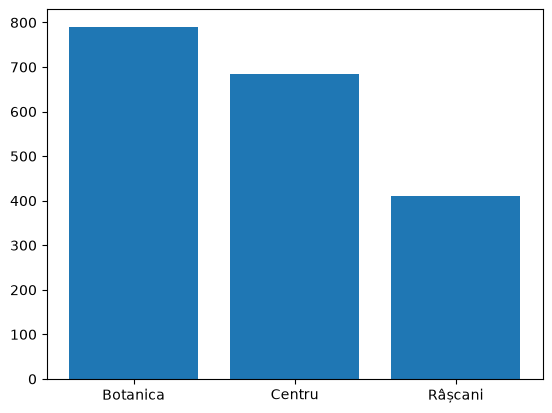

In [57]:
plt.bar(top_10['Sector'], top_10['Price (thousands of €)'])

According to the plot, Botanica contains one of the most luxurious apartments in Chisinau. Let's see the average price per sector. 

In [58]:
with open("../sql/queries/02_sector_avg.sql", encoding = 'utf-8') as f:
    query = f.read()
mean_sector1 = pd.read_sql_query(query,conn)
mean_sector1

,Sector,average
0,Centru,175.758360
1,Buiucani,161.620919
2,Râșcani,153.007130
3,Botanica,124.352470
4,Ciocana,124.168923


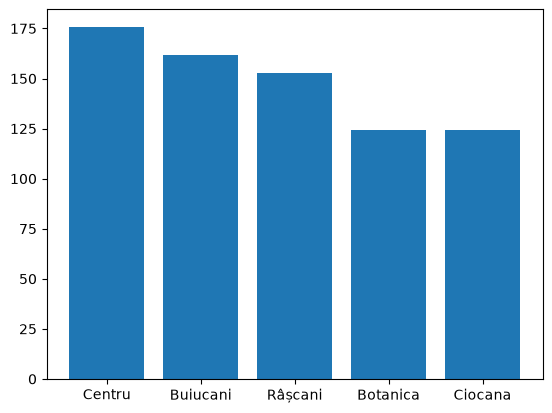

In [59]:
plt.bar(mean_sector1['Sector'],mean_sector1['average'])
plt.show()

In [60]:
comparison = df_analysis.groupby('Sector')['Price (thousands of €)'].agg(['median','mean'])
comparison['gap'] = comparison['mean'] - comparison['median']
comparison.sort_values('gap',ascending = False)

,median,mean,gap
Sector,,,
Centru,139.00,175.758360,36.758360
Râșcani,125.80,153.007130,27.207130
Buiucani,144.95,161.620919,16.670919
Botanica,109.90,124.352470,14.452470
Ciocana,118.90,124.168923,5.268923


From above illustration: Buiucani has the highest median price (144.95k), suggesting consistently high quality stock, while Centru shows the largest mean-median gap (36.7k), indicating a polarized market with both affordable Soviet-era apartments and premium properties coexisting in the same sector.

## Question 1 ANSWER:
Ciocana exhibits the smallest difference between mean and median apartment prices, indicating lower price dispersion compared with other sectors.

In [61]:
price = df_analysis['Price (thousands of €)']
sector = df_analysis['Sector']
area = df_analysis['Area m²']

<Axes: xlabel='Area m²', ylabel='Price (thousands of €)'>

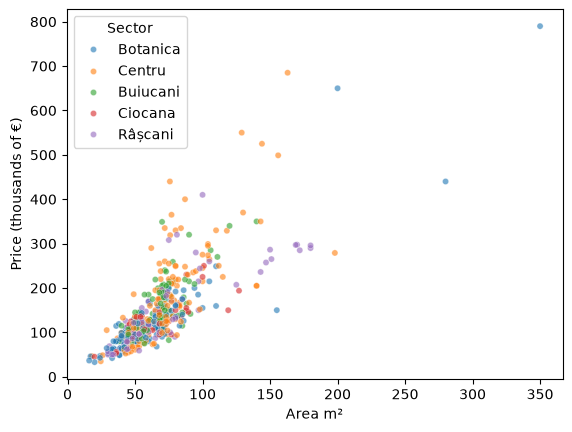

In [62]:
sns.scatterplot(df,x = area,y = price,hue = sector,s = 20,alpha = 0.6)


<function matplotlib.pyplot.show(close=None, block=None)>

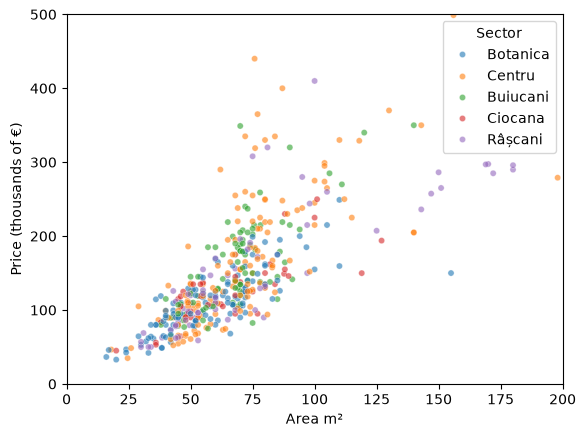

In [63]:
sns.scatterplot(df,x = area,y = price,hue = sector,s = 20,alpha = 0.6)
plt.xlim(0,200)
plt.ylim(0,500)
plt.show

In [64]:
price_per_m_squared =  df_analysis['Price per m² (thousands of €)']

<Axes: xlabel='Sector', ylabel='Price per m² (thousands of €)'>

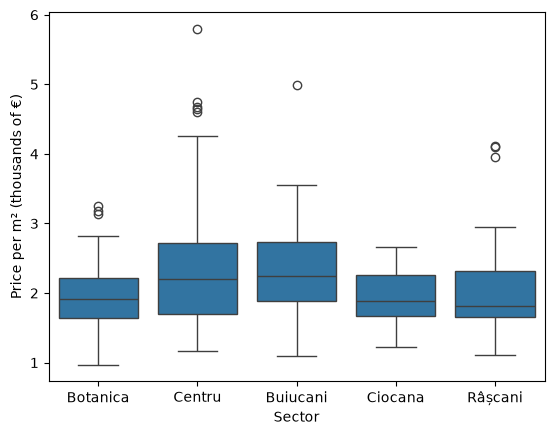

In [65]:
sns.boxplot(data = df_analysis,x = sector, y = price_per_m_squared)

In [66]:
corr = df_analysis.corr(numeric_only = True)

<Axes: >

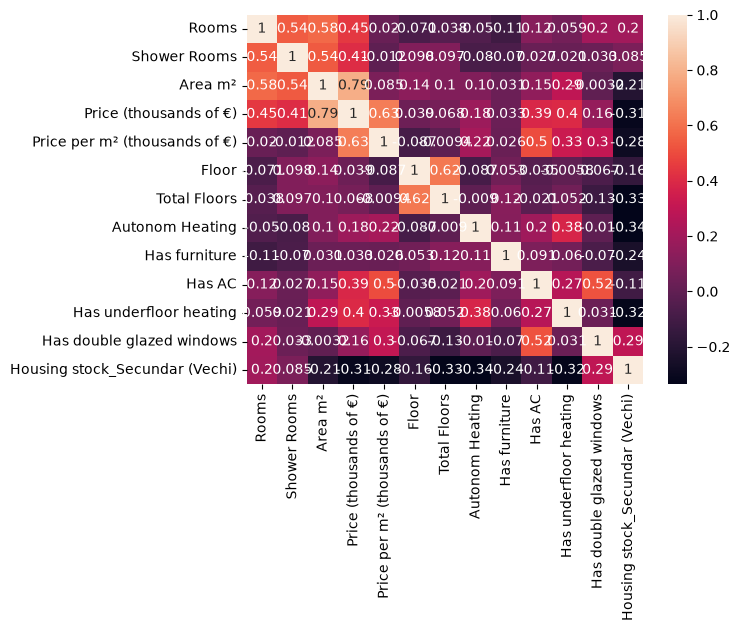

In [67]:
sns.heatmap(corr,annot = True)

## Question 2 ANSWER:
The heatmap above shows that area is dominant (!) in price determination.  
Plus, among 'has...' features, underfloor heating has the highest correlation with price.   
But let's try to answer the question - how important is sector compared to area?   
For this, a copy of df will be created. Outliers will be deleted with use of IQR

# Creating the model

In [68]:
df_model = df.copy()

I will remove outliers with IQR for a better Linear Regression model.

In [69]:
Q1 = df_model['Price (thousands of €)'].quantile(0.25)
Q3 = df_model['Price (thousands of €)'].quantile(0.75)
IQR = Q3 - Q1

In [70]:
df_model = df_model[(df_model['Price (thousands of €)'] >= Q1 - 1.5*IQR) & 
                    (df_model['Price (thousands of €)'] <= Q3 + 1.5*IQR)]

In [71]:
df_model.info()

<class 'pandas.DataFrame'>
Index: 426 entries, 0 to 573
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Title                           426 non-null    str    
 1   Sector                          426 non-null    str    
 2   Rooms                           426 non-null    int64  
 3   Shower Rooms                    426 non-null    int64  
 4   Area m²                         426 non-null    float64
 5   Price (thousands of €)          426 non-null    float64
 6   Price per m² (thousands of €)   426 non-null    float64
 7   Floor                           424 non-null    Int64  
 8   Total Floors                    424 non-null    Int64  
 9   Autonom Heating                 426 non-null    bool   
 10  Has furniture                   426 non-null    int64  
 11  Has AC                          426 non-null    int64  
 12  Has underfloor heating          426 non-null    int6

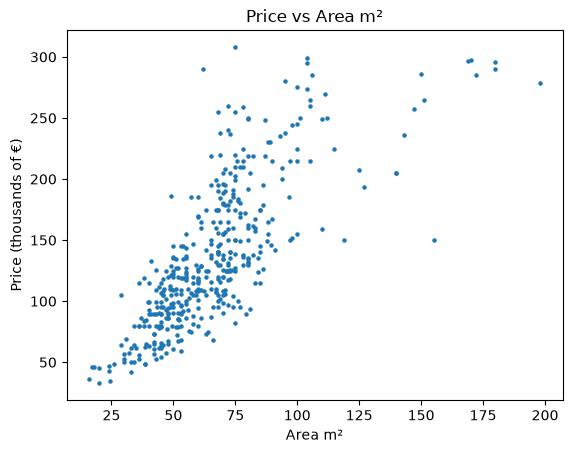

In [72]:
price = df_model['Price (thousands of €)']
area = df_model['Area m²']
plt.scatter(area,price,5)
plt.title('Price vs Area m²')
plt.xlabel('Area m²')
plt.ylabel('Price (thousands of €)')
plt.show()

 The above scatter plot shows the kind of dependency between price and area. It doesn't look linear. Two regressions - linear and logarithmic will be built to see which type it is

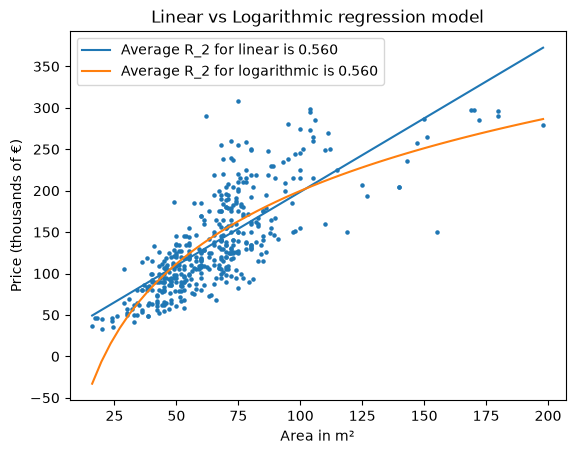

In [73]:
#Linear
X = df_model['Area m²'].values.reshape(-1,1)
Y = df_model['Price (thousands of €)'].values
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

linear_model = LinearRegression().fit(X_train,y_train)
r2_linear = r2_score(y_test,linear_model.predict(X_test))
# Logarithmic
log_model = LinearRegression().fit(np.log(X_train),y_train)
r2_log = r2_score(y_test,log_model.predict(np.log(X_test)))

cross_val_score_linear = cross_val_score(linear_model,X_train,y_train,cv=5,scoring='r2').mean()
cross_val_score_logarithmic = cross_val_score(log_model,X_train,y_train,cv=5,scoring='r2').mean()


x_range = np.linspace(X.min(),X.max(),50).reshape(-1,1)
plt.scatter(X,Y,5)
plt.plot(x_range,linear_model.predict(x_range), label = f'Average R_2 for linear is {cross_val_score_linear:.3f}')

plt.plot(x_range, log_model.predict(np.log(x_range)), label = f'Average R_2 for logarithmic is {cross_val_score_logarithmic:.3f}')

plt.title('Linear vs Logarithmic regression model')
plt.xlabel('Area in m²')
plt.ylabel('Price (thousands of €)')
plt.legend()
plt.show()

The R2 values for linear and logarithmic models identical, suggesting the area–price relationship is linear and does not change meaningfully with apartment size. Let's verify this by splitting apartments by size segment and comparing median price per m².

In [74]:
# Check average price/m² by size segment
df_model['Size segment'] = pd.cut(df_model['Area m²'], 
                                      bins=[0, 50, 80, 120, 300],
                                      labels=['Small', 'Medium', 'Large', 'Extra large'])

df_model.groupby('Size segment')['Price per m² (thousands of €)'].median()

Size segment
Small          2.00
Medium         2.00
Large          2.08
Extra large    1.65
Name: Price per m² (thousands of €), dtype: float64

In [75]:
df_model['Size segment'].value_counts()

Size segment
Medium         232
Small          120
Large           59
Extra large     15
Name: count, dtype: int64

## Question 3 ANSWER:
So it is (!)linear for apartments below 120m^2 with median price for m^2 ranging from 2000 - 2080 euros.  
But with extra large apartments there is a discount with 1650 euros being median price for m^2.  
It is good to notice there are only 15 extra large apartments so the drop might not be significant.  
More data is needed for future analysis

In [76]:
df_model = df_model.drop(['Size segment', 'Title', 'URL', 'Price per m² (thousands of €)'], axis = 1)

In [77]:
df_model.isna().sum()

Sector                            0
Rooms                             0
Shower Rooms                      0
Area m²                           0
Price (thousands of €)            0
Floor                             2
Total Floors                      2
Autonom Heating                   0
Has furniture                     0
Has AC                            0
Has underfloor heating            0
Has double glazed windows         0
Housing stock_Secundar (Vechi)    0
dtype: int64

Will drop those values with NaN values.

In [78]:
df_model = df_model.dropna(subset = 'Floor')
df_model = df_model.dropna(subset = 'Total Floors')

In [79]:
df_model.isna().sum()

Sector                            0
Rooms                             0
Shower Rooms                      0
Area m²                           0
Price (thousands of €)            0
Floor                             0
Total Floors                      0
Autonom Heating                   0
Has furniture                     0
Has AC                            0
Has underfloor heating            0
Has double glazed windows         0
Housing stock_Secundar (Vechi)    0
dtype: int64

In [80]:
df_model.head()

,Sector,Rooms,Shower Rooms,Area m²,Price (thousands of €),Floor,Total Floors,Autonom Heating,Has furniture,Has AC,Has underfloor heating,Has double glazed windows,Housing stock_Secundar (Vechi)
0,Botanica,1,1,42.0,73.5,5,12,True,1,0,0,0,False
1,Centru,2,1,53.0,109.0,1,9,True,1,0,0,1,True
2,Botanica,2,1,47.0,93.0,5,5,False,1,0,0,1,True
3,Botanica,2,1,75.0,175.0,8,10,True,1,1,1,1,False
4,Botanica,1,1,43.0,109.0,9,10,True,1,1,1,1,False


In [81]:
df_model['Shower Rooms'].dtype

dtype('int64')

In [82]:
scaler = StandardScaler()
X = df_model.drop(['Price (thousands of €)','Rooms','Shower Rooms'],axis = 1)
y = df_model['Price (thousands of €)']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

sector_mean = y_train.groupby(X_train['Sector']).mean()
X_train['Sector'] = X_train['Sector'].map(sector_mean)
X_test['Sector'] = X_test['Sector'].map(sector_mean)

overall_mean = y_train.mean()
X_test['Sector'] = X_test['Sector'].fillna(overall_mean)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = LinearRegression().fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2, mae

(0.7677342880060927, 22.218343139403864)

In [83]:
coefficients = pd.Series(model.coef_, index=X_train.columns)
coefficients.sort_values(ascending=False)

Area m²                           40.605935
Has double glazed windows         10.768087
Has AC                            10.208438
Total Floors                       6.193557
Sector                             5.828748
Has underfloor heating             5.758343
Autonom Heating                    0.096007
Has furniture                     -0.337528
Floor                             -5.865574
Housing stock_Secundar (Vechi)   -10.860341
dtype: float64

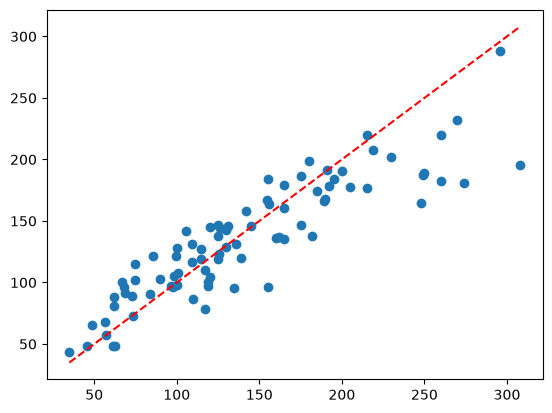

In [84]:
plt.scatter(y_test,model.predict(X_test_scaled))
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--')

In [85]:
coefficients['Area m²']/coefficients['Sector']

np.float64(6.966493121748862)

## Question 4 ANSWER:
Area is 6.9x more influential than sector(!) in determining property price, according to coefficients.

## Experimenting with RandomForestRegressor

In [86]:
X_rf = df_model.drop(['Price (thousands of €)',],axis = 1)
y_rf = df_model['Price (thousands of €)']
X_train_rf,X_test_rf, y_train_rf, y_test_rf = train_test_split (X_rf, y_rf, test_size = 0.2, random_state = 42)

sector_mean_rf = y_train_rf.groupby(X_train_rf['Sector']).mean()
X_train_rf['Sector'] = X_train_rf['Sector'].map(sector_mean_rf)
X_test_rf['Sector'] = X_test_rf['Sector'].map(sector_mean_rf)

overall_mean_rf = y_train.mean()
X_test_rf['Sector'] = X_test_rf['Sector'].fillna(overall_mean_rf)

In [87]:
rf = RandomForestRegressor(random_state = 42)
rf.fit(X_train_rf,y_train_rf)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [88]:
y_pred_rf = rf.predict(X_test_rf)
r2_rf = r2_score(y_test_rf,y_pred_rf)
mae_rf = mean_absolute_error(y_test_rf, y_pred_rf)
r2_rf, mae_rf

(0.7452400744791352, 23.1799734789916)

In [89]:
cross_val_score_lr = cross_val_score(model,X_train_scaled,y_train,cv=5,scoring='r2').mean()
cross_val_score_rf = cross_val_score(rf,X_train_rf,y_train_rf,cv=5,scoring ='r2').mean()

In [90]:
df_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'RandomForestRegressor'],
    'Average R2': [cross_val_score_lr, cross_val_score_rf],
    'Mean absolute error': [mae, mae_rf],
})
df_comparison

,Model,Average R2,Mean absolute error
0,Linear Regression,0.744359,22.218343
1,RandomForestRegressor,0.754286,23.179973


We can see what RandomForestRegression has a higher average R^2 and lower mean absolute value.
It is so because price is not totally dependent by the area, even if it is the most dominating feature.

In [91]:
df_feature_importance = pd.DataFrame(
    {
        'Feature': X_train_rf.columns,
        'Importance': rf.feature_importances_
    }
)
df_feature_importance

,Feature,Importance
0,Sector,0.031853
1,Rooms,0.005737
2,Shower Rooms,0.007540
3,Area m²,0.728576
4,Floor,0.040004
5,Total Floors,0.038838
6,Autonom Heating,0.011679
7,Has furniture,0.000516
8,Has AC,0.081356
9,Has underfloor heating,0.020247


<BarContainer object of 12 artists>

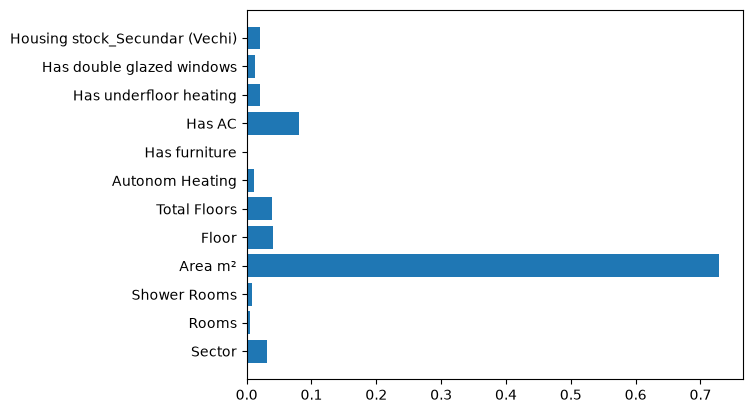

In [92]:
plt.barh(df_feature_importance['Feature'],df_feature_importance['Importance'])

We can see what area's dominance in comparison with other features.

In [93]:
conn.close()